In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
###### the spreading of failures
import sys
import pickle,itertools
import copy
import os

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import pandas as pd

#date_string = datetime.datetime.now().strftime("%I_%M_%B_%d")

path = '/media/fkaiser/'

sys.path.append('../power_system_split/')
import utils,visualisation

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/xarray/backends/cfgrib_.py:27: UserWarning: Failed to load cfgrib - most likely there is a problem accessing the ecCodes library. Try `import cfgrib` to get the full error message
  warnings.warn(


## Evaluate cluster

In [104]:
co2l = 0.0

path_to_pypsa_network = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l) # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

#G = utils.build_networkx_graph(network)
criterion = 'nodes'
snet_index = 0
G_snet = utils.build_networkx_graph(network, snet_index = snet_index)

splitting_cascades = pickle.load(open(results_path+'system_splits_Co2L%.1f.pickle' % (co2l),'rb'))

solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_'%co2l+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))

indicator_vectors, component_props = visualisation.indicator_vectors_from_rocof_solution(solution_dict, 
                                                                                         splitting_cascades, 
                                                                                         G_snet, 
                                                                                         criterion = criterion)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [106]:
component_props.shape

(0, 5)

In [107]:
split_component_props = pd.DataFrame(columns=['time_stamp',
                                              'number_of_split',
                                              'inertia_proxy',
                                              'load_imbalance',
                                              'available_flexible_generation'],
                                     index=[], dtype=float)

time_stamp = 1
split_number = 1

      
props = {'time_stamp': time_stamp,
                     'number_of_split': split_number,
                     'inertia_proxy': split_number,#component_props['inertia_proxy'][j],
                     'load_imbalance': split_number,#component_props['load_imbalance'][j],
                     'available_flexible_generation': split_number#component_props['available_flexible_generation'][j]
                     }
            
split_component_props.append(props, ignore_index=True)

,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation
0,1.0,1.0,1.0,1.0,1.0


In [98]:
min_cluster_distance = 100./ len(G_snet.nodes())
n_cluster, cluster_labels = visualisation.cluster_indicator_vectors(indicator_vectors, 
                                                                    min_cluster_distance=min_cluster_distance)

n_cols = 3
n_rows = np.ceil(n_cluster/n_cols).astype(int)


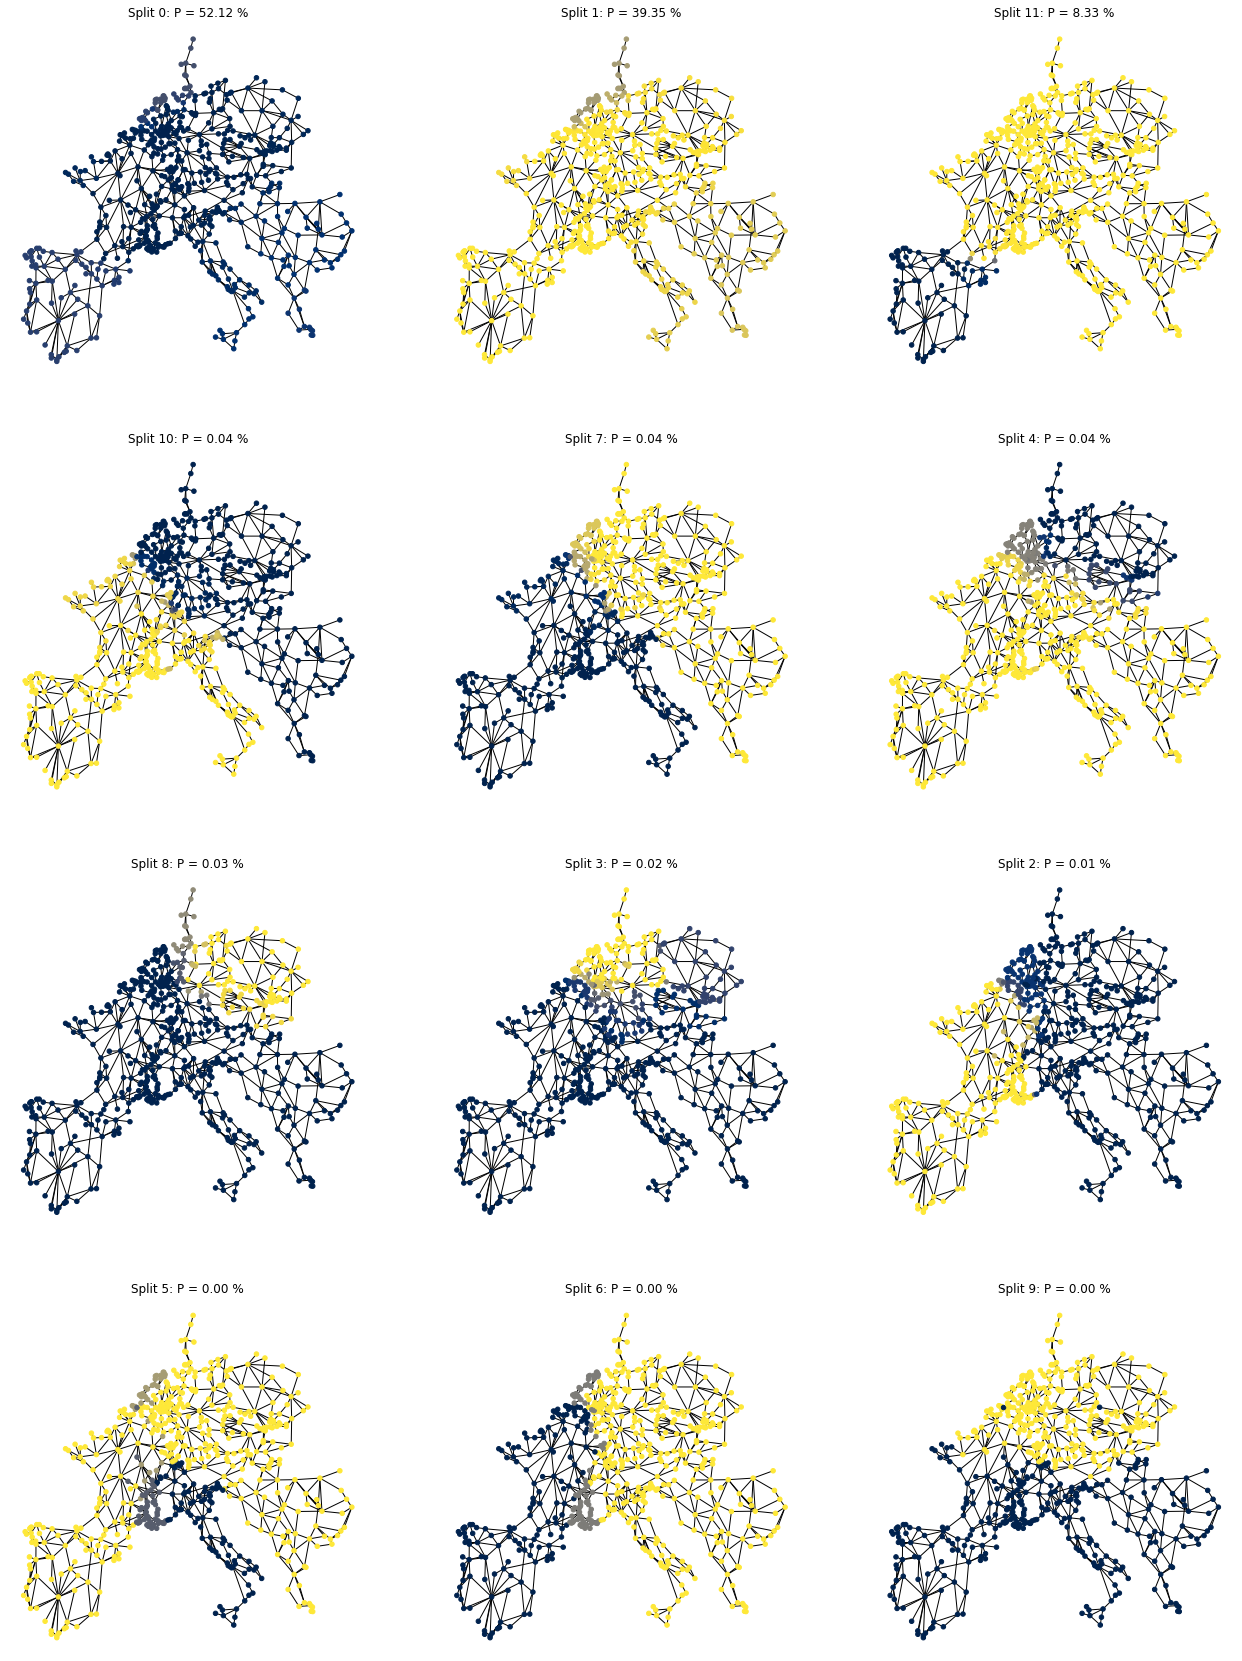

In [99]:
fig,ax = plt.subplots(n_rows,n_cols,figsize=(22,30))

visualisation.plot_component_cluster(indicator_vectors, ax.flatten()[:n_cluster],
                                     cluster_labels, G_snet)

In [101]:
component_props['time_stamp']

Series([], Name: time_stamp, dtype: float64)

In [212]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))

number_of_simulations = len(non_bridges)*len(solution_dict.keys())

cluster_props = split_component_results.groupby('cluster_label').size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = split_component_results.groupby('cluster_label')['number_of_nodes'].mean()
cluster_props.loc[:,'mean_rocof'] = split_component_results.groupby('cluster_label')['rocof'].mean()
cluster_props

,counts,likelihood,mean_number_of_nodes,mean_rocof
cluster_label,,,,
0.0,26,9.313922e-06,88.538462,2.961028
1.0,26,9.313922e-06,513.923077,2.673681
2.0,11,3.940506e-06,451.545455,0.183376
3.0,274,9.815441e-05,2.029197,2.375328
4.0,11,3.940506e-06,63.272727,5.377162
5.0,12,4.298733e-06,61.666667,144.823643
7.0,1,3.582278e-07,362.000000,3.664409


In [65]:
for time_stamp in solution_dict.keys():
    
    if not solution_dict[time_stamp]:
        continue
    
    for i, split_number in enumerate(solution_dict[time_stamp][::2]):
        print(i,i*2+1)
        split = splitting_cascades[time_stamp][split_number]
        components = utils.get_split_components(split, G_snet, criterion = criterion)

        component_props = solution_dict[time_stamp][i*2+1]
        if len(component_props['inertia_proxy']) != len(components):
            print(time_stamp)
        for j, component in enumerate(components):
            pass

0 1
0 1
0 1
0 1
0 1
05_03_2013_09
0 1
0 1
0 1
0 1
19_11_2013_18
0 1
0 1
25_12_2013_21


In [76]:
tstamp = '25_12_2013_21'
for i, split_number in enumerate(solution_dict[tstamp][::2]):
    print(i,split_number)
    split = splitting_cascades[tstamp][split_number]
    print(split)
    components = utils.get_split_components(split, G_snet, criterion = criterion)
    print(len(components))
    for component in components:
        print(len(component.nodes()))
    print(len(solution_dict[tstamp][1]['inertia_proxy']))

0 25
[('FR0 115', 'FR0 7'), ('FR0 101', 'FR0 70'), ('FR0 117', 'FR0 52'), ('FR0 115', 'FR0 108'), ('FR0 117', 'FR0 40'), ('FR0 117', 'FR0 45'), ('ES0 35', 'FR0 6'), ('FR0 45', 'FR0 119'), ('ES0 29', 'FR0 18'), ('FR0 115', 'FR0 117'), ('FR0 102', 'FR0 99'), ('FR0 99', 'FR0 119'), ('FR0 94', 'FR0 53'), ('FR0 106', 'FR0 23'), ('FR0 106', 'FR0 29'), ('FR0 101', 'FR0 115'), ('FR0 101', 'FR0 117'), ('FR0 117', 'FR0 53'), ('FR0 23', 'FR0 17'), ('FR0 29', 'FR0 17'), ('FR0 119', 'FR0 53')]
6
520
79
2
2
1
4
5


In [83]:
#for split in splitting_cascades[tstamp]:
split = splitting_cascades[tstamp][split_number]
components = utils.get_split_components(split, G_snet, criterion = criterion)
print(len(components))
Graph              = utils.build_networkx_graph(network,snet_index)
print(len(Graph.nodes()) == len(G_snet.nodes()))
results = utils.evaluate_split_observables(split,
                                                   network,
                                                   utils.solution_key_to_pandas_timestamp(tstamp),
                                                   use_pnom = True,
                                                   criterion = criterion,
                                                   snet_index = snet_index)
print(results['inertia_proxy'])


6
False
[205079.99366383356, 10725.062356851897, 0.0, 0.0, 2742.253988593788]


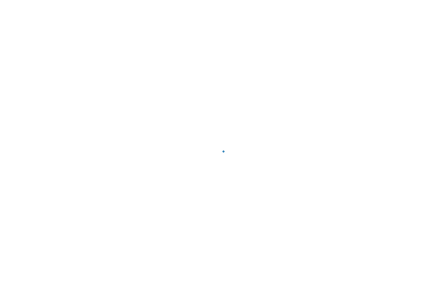

In [48]:
nx.draw(components[1],pos = nx.get_node_attributes(G_snet,'pos'),node_size = 1)

In [4]:
len(G_snet.nodes())

608

In [5]:
len(G.nodes())

800

In [31]:
#for i in range(50):
#    timestamp = list(solution_dict.keys())[i]
#    if len(solution_dict[timestamp]):
#        print(timestamp)
#        print(solution_dict[timestam p])
timestamp = '06_10_2013_00'
#solution_dict[timestamp]
for timestamp in solution_dict.keys():
    if len(solution_dict[timestamp]):
        the_cascade = splitting_cascades[timestamp][solution_dict[timestamp][0]]
        s0 = (len(solution_dict[timestamp][1]['inertia_proxy']))
        split_comps = utils.get_split_components(the_cascade,G_snet,'load')
        s1 = len(split_comps)
        if s0 != s1:
            print(timestamp)

07_05_2013_06
09_05_2013_21
10_05_2013_03
11_05_2013_18
11_05_2013_21
12_05_2013_21
20_05_2013_09
24_05_2013_18
28_05_2013_09
29_05_2013_09
31_05_2013_18
31_05_2013_21
01_06_2013_00
01_06_2013_03
12_06_2013_12
13_06_2013_06
17_06_2013_00
20_06_2013_09
30_06_2013_21
03_02_2013_18
04_02_2013_18
06_02_2013_06
14_02_2013_21
15_02_2013_09
17_02_2013_09
17_02_2013_21
18_02_2013_09
19_02_2013_09
19_02_2013_15
20_02_2013_15
20_02_2013_18
20_02_2013_21
21_02_2013_15
23_02_2013_15
23_02_2013_21
03_03_2013_18
04_03_2013_09
05_03_2013_15
05_03_2013_18
06_03_2013_06
06_03_2013_09
06_03_2013_12
07_03_2013_06
07_03_2013_21
08_03_2013_03
08_03_2013_06
14_03_2013_09
15_03_2013_09
18_03_2013_06
20_03_2013_18
22_03_2013_09
25_03_2013_00
02_08_2013_03
03_08_2013_09
05_08_2013_09
08_08_2013_09
08_08_2013_18
08_08_2013_21
10_08_2013_09
10_08_2013_12
10_08_2013_21
13_08_2013_12
18_08_2013_06
24_08_2013_15
25_08_2013_12
27_08_2013_09
29_08_2013_09
31_08_2013_12
04_09_2013_09
04_09_2013_12
04_09_2013_15
04_09_

In [35]:
timestamp = '02_11_2013_03'
the_cascade = splitting_cascades[timestamp][solution_dict[timestamp][0]]
criterion = 'load'
print(len(utils.get_split_components(the_cascade,
                                     G_snet,
                                     criterion = criterion)))
print(the_cascade)
results = utils.evaluate_split_observables(the_cascade,
                                                   network,
                                                   utils.solution_key_to_pandas_timestamp(timestamp),
                                                   use_pnom = True,
                                                   criterion = criterion,
                                                   snet_index = snet_index)
print(results['inertia_proxy'])

#evaluate_split_observables(the_cascade,
#                               G_snet,
#                               timestamp,

4
[('FR0 117', 'FR0 119'), ('FR0 94', 'FR0 53'), ('FR0 119', 'FR0 53'), ('ES0 12', 'FR0 94'), ('FR0 45', 'FR0 119'), ('ES0 29', 'FR0 18'), ('FR0 106', 'FR0 102'), ('FR0 117', 'FR0 45'), ('FR0 102', 'FR0 99'), ('FR0 108', 'FR0 40'), ('ES0 35', 'FR0 6'), ('FR0 6', 'FR0 115'), ('FR0 10', 'FR0 69'), ('FR0 100', 'FR0 106'), ('FR0 100', 'FR0 95'), ('FR0 106', 'FR0 95'), ('FR0 115', 'FR0 108')]
[123979.49621986003, 13705.382356851896]


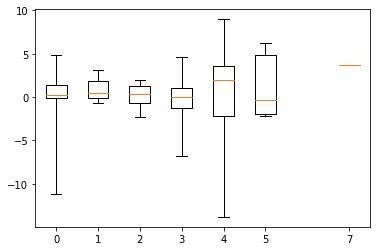

In [211]:
_= plt.boxplot(split_component_results.groupby('cluster_label')['rocof'].apply(list).values,
               positions=component_likelihoods.index,
               showfliers=False,
               whis=[10,90])